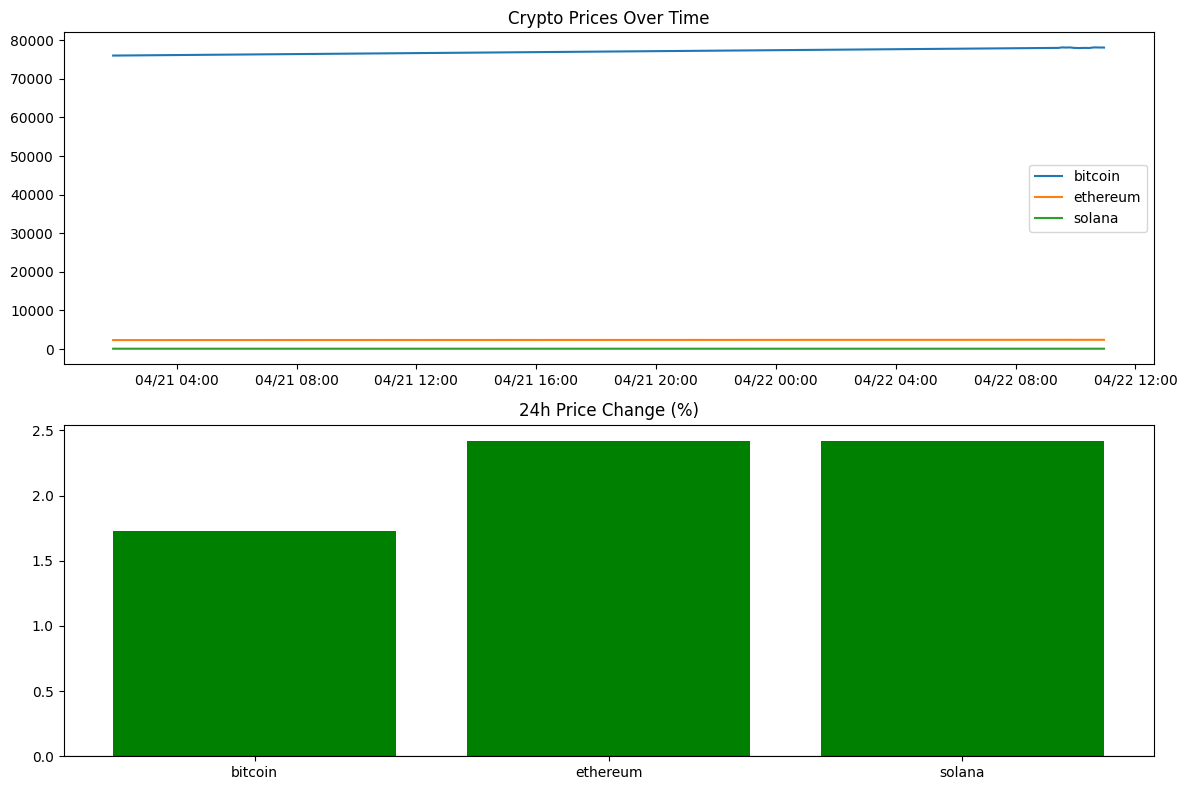

In [ ]:
import os
import awswrangler as wr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

In [31]:
df = wr.athena.read_sql_query(
    sql="""
        SELECT timestamp, coin, price_usd, change_24h_pct
        FROM crypto_db.processed
        ORDER BY timestamp ASC
    """,
    database="crypto_db",
    s3_output="s3://crypto-athena-results-ralph/"
)

In [32]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

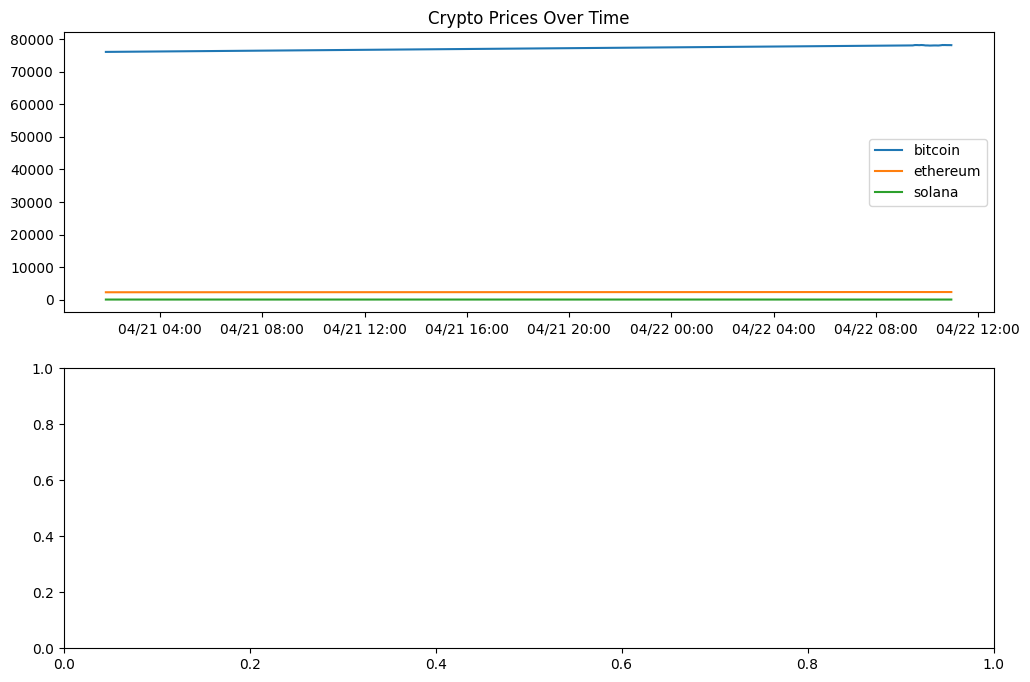

In [33]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

for coin in ['bitcoin', 'ethereum', 'solana']:
    subset = df[df['coin'] == coin]
    axes[0].plot(subset['timestamp'], subset['price_usd'], label=coin)

axes[0].set_title('Crypto Prices Over Time')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%m/%d %H:%M'))

In [34]:
latest = df.groupby('coin').last().reset_index()
axes[1].bar(latest['coin'], latest['change_24h_pct'],
            color=['green' if x > 0 else 'red' for x in latest['change_24h_pct']])
axes[1].set_title('24h Price Change (%)')
axes[1].axhline(0, color='black', linewidth=0.8)

plt.tight_layout()
os.makedirs('../screenshots', exist_ok=True)
plt.savefig('../screenshots/price_chart.png', dpi=150)
plt.show()

<Figure size 640x480 with 0 Axes>

In [ ]:
import awswrangler as wr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Query Athena directly from Python
df = wr.athena.read_sql_query(
    sql="""
        SELECT timestamp, coin, price_usd, change_24h_pct
        FROM crypto_db.processed
        ORDER BY timestamp ASC
    """,
    database="crypto_db",
    s3_output="s3://crypto-athena-results-yourname/"
)

df['timestamp'] = pd.to_datetime(df['timestamp'])

# Plot BTC price over time
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

for coin in ['bitcoin', 'ethereum', 'solana']:
    subset = df[df['coin'] == coin]
    axes[0].plot(subset['timestamp'], subset['price_usd'], label=coin)

axes[0].set_title('Crypto Prices Over Time')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%m/%d %H:%M'))

# Plot 24h change
latest = df.groupby('coin').last().reset_index()
axes[1].bar(latest['coin'], latest['change_24h_pct'],
            color=['green' if x > 0 else 'red' for x in latest['change_24h_pct']])
axes[1].set_title('24h Price Change (%)')
axes[1].axhline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('../screenshots/price_chart.png', dpi=150)
plt.show()